In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Milestone 4: SABR Calibration

This notebook turns the SABR smile module into a calibration workflow. The emphasis is on fitting quality, diagnostics, parameter stability, and preparation for low-rate or negative-rate extensions.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.pricing.european import price_shifted_black
from swaption_pricing.pricing.european import (
    calibrate_sabr_across_beta_values,
    calibrate_sabr_for_multiple_initial_guesses,
    calibrate_sabr_to_vols,
    calibration_diagnostics,
    calibration_rows,
)
from swaption_pricing.pricing.european import SabrParams, sabr_implied_volatility, shifted_sabr_implied_volatility

## 1. Calibration Objective

For one strike slice, the calibration problem is:

$$
\min_{\alpha,\rho,\nu} \sum_i \left(\sigma^{\text{model}}(K_i) - \sigma^{\text{market}}(K_i)\right)^2
$$

In this project, `beta` is fixed during calibration and we solve for:

- `alpha`
- `rho`
- `nu`

This is the standard simplified SABR calibration setup and keeps the optimization stable enough for a first research implementation.

## 2. Build a Synthetic Market Smile

We first use synthetic market vols generated from known SABR parameters. This validates that the calibration engine can recover a known parameter set before any market-data complications are introduced.

In [3]:
forward = 0.0400
expiry = 2.0
strikes = [0.0300, 0.0350, 0.0400, 0.0450, 0.0500]
true_params = SabrParams(alpha=0.0200, beta=0.50, rho=-0.25, nu=0.40)
market_vols = [sabr_implied_volatility(forward, strike, expiry, true_params) for strike in strikes]

market_df = pd.DataFrame({'strike': strikes, 'market_vol': market_vols})
market_df

,strike,market_vol
0,0.030,0.136344
1,0.035,0.115907
2,0.040,0.102188
3,0.045,0.097054
4,0.050,0.098932


## 3. Base Calibration Result

In [4]:
base_result = calibrate_sabr_to_vols(
    forward,
    strikes,
    expiry,
    market_vols,
    beta=0.50,
    initial_guess=(0.0180, -0.10, 0.30),
)
base_diagnostics = calibration_diagnostics(base_result)

pd.DataFrame([
    {'metric': 'alpha', 'value': base_result.params.alpha},
    {'metric': 'beta', 'value': base_result.params.beta},
    {'metric': 'rho', 'value': base_result.params.rho},
    {'metric': 'nu', 'value': base_result.params.nu},
    {'metric': 'objective_value', 'value': base_result.objective_value},
    {'metric': 'max_abs_error', 'value': base_diagnostics.max_abs_error},
    {'metric': 'mean_abs_error', 'value': base_diagnostics.mean_abs_error},
    {'metric': 'rmse', 'value': base_diagnostics.rmse},
])

,metric,value
0,alpha,2.000000e-02
1,beta,5.000000e-01
2,rho,-2.500000e-01
3,nu,4.000000e-01
4,objective_value,3.710995e-20
5,max_abs_error,1.653078e-10
6,mean_abs_error,7.030849e-11
7,rmse,8.615098e-11


## 4. Fitted vs Market Vol and Residuals

In [5]:
rows_df = pd.DataFrame([row.__dict__ for row in calibration_rows(base_result)])
rows_df

,strike,market_vol,fitted_vol,residual
0,0.030,0.136344,0.136344,4.746090e-11
1,0.035,0.115907,0.115907,-4.662465e-11
2,0.040,0.102188,0.102187,-6.964533e-11
3,0.045,0.097054,0.097054,2.250379e-11
4,0.050,0.098932,0.098932,1.653078e-10


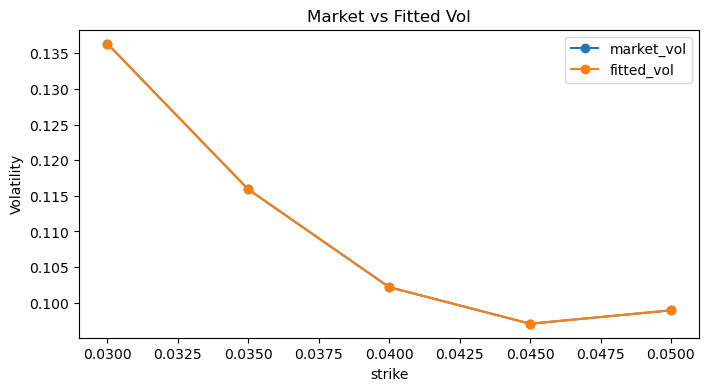

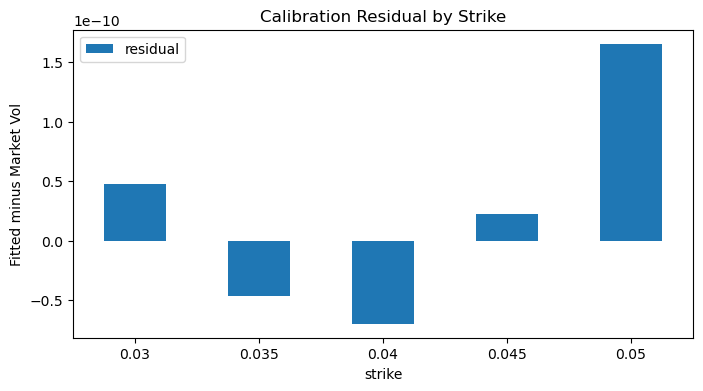

In [6]:
ax = rows_df.plot(x='strike', y=['market_vol', 'fitted_vol'], marker='o', figsize=(8, 4), title='Market vs Fitted Vol')
ax.set_ylabel('Volatility')
plt.show()

ax = rows_df.plot(x='strike', y='residual', kind='bar', figsize=(8, 4), title='Calibration Residual by Strike')
ax.set_ylabel('Fitted minus Market Vol')
plt.xticks(rotation=0)
plt.show()

## 5. Sensitivity to Initial Guess

A stable calibration should not be overly sensitive to reasonable initial guesses. Here we run the optimizer from multiple starting points and compare recovered parameters and RMSE.

In [7]:
guess_results = calibrate_sabr_for_multiple_initial_guesses(
    forward,
    strikes,
    expiry,
    market_vols,
    beta=0.50,
    initial_guesses=[(0.0180, -0.10, 0.30), (0.0300, -0.50, 0.80), (0.0100, 0.20, 0.20)],
)

guess_df = pd.DataFrame([
    {
        'run': idx + 1,
        'alpha': result.params.alpha,
        'rho': result.params.rho,
        'nu': result.params.nu,
        'rmse': calibration_diagnostics(result).rmse,
        'success': result.success,
    }
    for idx, result in enumerate(guess_results)
])
guess_df

,run,alpha,rho,nu,rmse,success
0,1,0.02,-0.25,0.4,8.615098e-11,True
1,2,0.02,-0.25,0.4,7.508740e-12,True
2,3,0.02,-0.25,0.4,6.000544e-11,True


## 6. Sensitivity to Fixed Beta

In practice, beta is often fixed rather than calibrated. This section shows how the recovered parameters and fit quality change across different beta assumptions.

In [8]:
beta_results = calibrate_sabr_across_beta_values(
    forward,
    strikes,
    expiry,
    market_vols,
    beta_values=[0.0, 0.5, 1.0],
    initial_guess=(0.0180, -0.10, 0.30),
)

beta_df = pd.DataFrame([
    {
        'beta': result.params.beta,
        'alpha': result.params.alpha,
        'rho': result.params.rho,
        'nu': result.params.nu,
        'rmse': calibration_diagnostics(result).rmse,
    }
    for result in beta_results
])
beta_df

,beta,alpha,rho,nu,rmse
0,0.0,0.003991,-0.107608,0.378626,2.514190e-04
1,0.5,0.020000,-0.250000,0.400000,8.615098e-11
2,1.0,0.100576,-0.373335,0.428778,2.632388e-04


## 7. Shifted Framework for Negative Rates

The current positive-rate SABR approximation depends on terms like $\ln(F/K)$, so it is not directly valid when the forward or strike are non-positive. A practical first extension is to add a positive shift before applying the lognormal framework.

In [9]:
negative_forward = -0.0020
negative_strike = -0.0010
shift = 0.0300
shifted_vol = shifted_sabr_implied_volatility(negative_forward, negative_strike, expiry, true_params, shift)
shifted_black_payoff = price_shifted_black(negative_forward, negative_strike, expiry, shifted_vol, shift, 'payer')

pd.DataFrame([
    {'metric': 'negative_forward', 'value': negative_forward},
    {'metric': 'negative_strike', 'value': negative_strike},
    {'metric': 'shift', 'value': shift},
    {'metric': 'shifted_sabr_vol', 'value': shifted_vol},
    {'metric': 'shifted_black_payoff', 'value': shifted_black_payoff},
])

,metric,value
0,negative_forward,-0.002000
1,negative_strike,-0.001000
2,shift,0.030000
3,shifted_sabr_vol,0.119498
4,shifted_black_payoff,0.001460


## 8. Why Negative Rates Matter

The shifted framework is only a first extension. In practice, low-rate and negative-rate environments raise a model-regime decision:

- `shifted Black`: add a positive shift before applying the lognormal formula
- `shifted SABR`: apply SABR to shifted rates and map the implied vol back into shifted Black pricing
- `normal/Bachelier`: switch to a normal-vol framework instead of lognormal

For this project, negative-rate support belongs in the calibration and market-convention layer, not just as a local patch to the positive-rate smile formula.

## 9. Interpretation

- Calibration solves for the SABR parameters that best fit a volatility smile slice.
- Diagnostics such as residuals and RMSE are necessary to judge fit quality.
- Multiple initial guesses help assess optimization stability.
- Fixed beta is a modeling choice, and changing it can alter both fitted parameters and error.
- Shifted Black and shifted SABR provide a practical first path for negative-rate handling under a lognormal-style framework.

This completes the first practical calibration workflow and establishes a first implementation path for low-rate extensions.